# Topic 3: Friend Recommendation on Social Networks
## 1. Setup and Data Loading
## 2. Graph Construction and Data Cleaning
## 3. Basic Network Analysis
## 4. Future Edge Definition
## 5. Candidate Edge Generation
## 6. Baseline Link Prediction Methods
## 7. Ranking and Top-K Evaluation
## 8. Supervised Extension
## 9. Result Comparison and Discussion

1. Setup and Data Loading

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import random

random.seed(42)
np.random.seed(42)

2. Graph Construction and Data Cleaning

In [2]:
def load_graph(edge_file):
    """
    Load an undirected graph from an edge list file and remove self-loops.
    """
    G = nx.read_edgelist(edge_file, nodetype=int, create_using=nx.Graph())
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

train_path = "/content/data/CA-AstroPh-train.txt"
test_path = "/content/data/CA-AstroPh-test.txt"

G_train = load_graph(train_path)
G_test = load_graph(test_path)

print("Train graph loaded.")
print("Test graph loaded.")
print(f"Train graph: {G_train.number_of_nodes()} nodes, {G_train.number_of_edges()} edges")
print(f"Test graph:  {G_test.number_of_nodes()} nodes, {G_test.number_of_edges()} edges")

Train graph loaded.
Test graph loaded.
Train graph: 18616 nodes, 178387 edges
Test graph:  11517 nodes, 19663 edges


In [3]:
train_edges = set((min(u, v), max(u, v)) for u, v in G_train.edges())
test_edges = set((min(u, v), max(u, v)) for u, v in G_test.edges())

overlap_edges = train_edges & test_edges
future_edges = test_edges - train_edges

print(f"Number of overlapping edges: {len(overlap_edges)}")
print(f"Number of future edges: {len(future_edges)}")

Number of overlapping edges: 0
Number of future edges: 19663


In [4]:
print(f"Train self-loops: {nx.number_of_selfloops(G_train)}")
print(f"Test self-loops: {nx.number_of_selfloops(G_test)}")

Train self-loops: 0
Test self-loops: 0


3. Basic Network Analysis

In [5]:
def graph_statistics(G, graph_name):
    degrees = dict(G.degree())
    degree_values = list(degrees.values())

    avg_degree = sum(degree_values) / len(degree_values) if degree_values else 0
    max_degree = max(degree_values) if degree_values else 0
    density = nx.density(G)
    num_components = nx.number_connected_components(G)
    avg_clustering = nx.average_clustering(G)

    summary = pd.DataFrame([{
        "Graph": graph_name,
        "Number of Nodes": G.number_of_nodes(),
        "Number of Edges": G.number_of_edges(),
        "Average Degree": round(avg_degree, 4),
        "Maximum Degree": max_degree,
        "Graph Density": round(density, 8),
        "Connected Components": num_components,
        "Average Clustering Coefficient": round(avg_clustering, 6)
    }])

    degree_distribution = pd.Series(degree_values).value_counts().sort_index().reset_index()
    degree_distribution.columns = ["Degree", "Count"]

    return summary, degree_distribution

In [6]:
train_summary, train_degree_distribution = graph_statistics(G_train, "Train")
test_summary, test_degree_distribution = graph_statistics(G_test, "Test")

graph_summary_table = pd.concat([train_summary, test_summary], ignore_index=True)
graph_summary_table

,Graph,Number of Nodes,Number of Edges,Average Degree,Maximum Degree,Graph Density,Connected Components,Average Clustering Coefficient
0,Train,18616,178387,19.1649,461,0.001030,282,0.551517
1,Test,11517,19663,3.4146,49,0.000297,730,0.032197


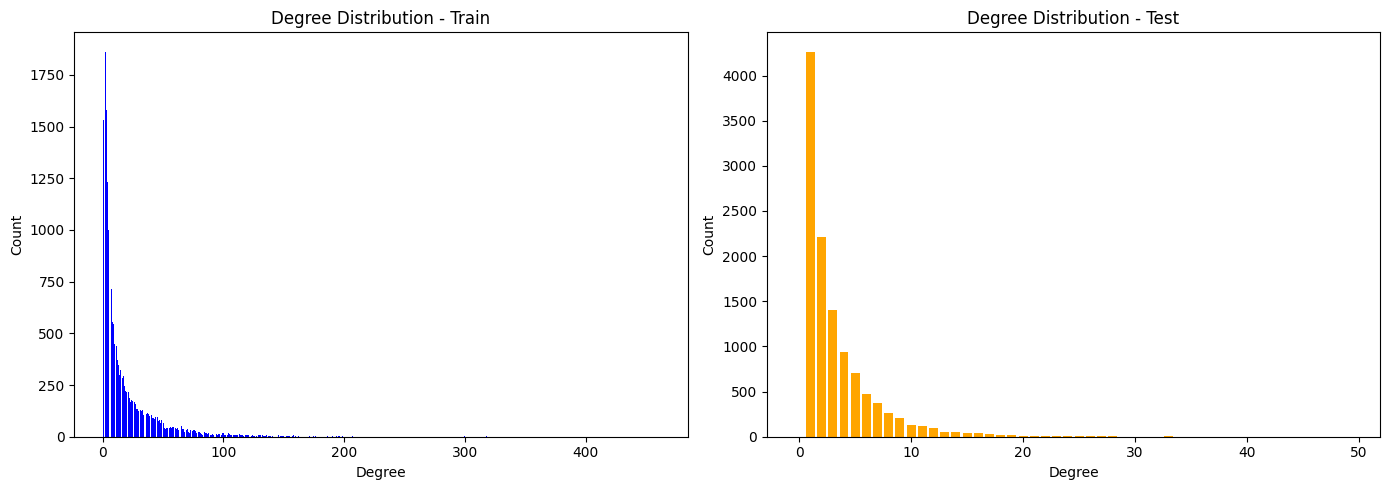

In [7]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(train_degree_distribution["Degree"], train_degree_distribution["Count"], color="blue")
plt.title("Degree Distribution - Train")
plt.xlabel("Degree")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.bar(test_degree_distribution["Degree"], test_degree_distribution["Count"], color="orange")
plt.title("Degree Distribution - Test")
plt.xlabel("Degree")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

4: Future Edge Definition


In [8]:
print(f"Number of train edges: {len(train_edges)}")
print(f"Number of test edges: {len(test_edges)}")
print(f"Number of overlapping edges: {len(overlap_edges)}")
print(f"Number of future edges: {len(future_edges)}")

# show a few example future edges
print("Sample future edges:", list(future_edges)[:10])

Number of train edges: 178387
Number of test edges: 19663
Number of overlapping edges: 0
Number of future edges: 19663
Sample future edges: [(64747, 101052), (22105, 74844), (48487, 88012), (87485, 89458), (108108, 124668), (90879, 94797), (101797, 103749), (29228, 117676), (99239, 126948), (26886, 52046)]


5. Candidate Edge Generation

In [9]:
def sample_negative_edges(G, forbidden_edges, num_samples, seed=42):
    random.seed(seed)
    nodes = list(G.nodes())
    negative_edges = set()

    while len(negative_edges) < num_samples:
        u, v = random.sample(nodes, 2)
        edge = (min(u, v), max(u, v))

        if edge in forbidden_edges:
            continue
        if G.has_edge(u, v):
            continue

        negative_edges.add(edge)

    return negative_edges

In [16]:
# forbidden edges = all train edges + all predictable future edges
forbidden_edges = train_edges | predictable_future_edges

negative_candidate_edges = sample_negative_edges(
    G_train,
    forbidden_edges=forbidden_edges,
    num_samples=len(predictable_future_edges),
    seed=42
)

candidate_edges = list(predictable_future_edges) + list(negative_candidate_edges)

print(f"Number of predictable future edges (positive candidates): {len(predictable_future_edges)}")
print(f"Number of sampled negative candidate edges: {len(negative_candidate_edges)}")
print(f"Total number of candidate edges: {len(candidate_edges)}")

Number of predictable future edges (positive candidates): 19512
Number of sampled negative candidate edges: 19512
Total number of candidate edges: 39024


In [15]:
# Filter future edges: keep only those whose two endpoints both exist in G_train
train_nodes = set(G_train.nodes())

predictable_future_edges = {
    (u, v) for (u, v) in future_edges
    if u in train_nodes and v in train_nodes
}

print(f"Original number of future edges: {len(future_edges)}")
print(f"Predictable future edges: {len(predictable_future_edges)}")
print(f"Unpredictable future edges: {len(future_edges) - len(predictable_future_edges)}")

Original number of future edges: 19663
Predictable future edges: 19512
Unpredictable future edges: 151


In [17]:
candidate_labels = {}

for edge in predictable_future_edges:
    candidate_labels[edge] = 1

for edge in negative_candidate_edges:
    candidate_labels[edge] = 0

print("Sample labeled candidates:")
for item in list(candidate_labels.items())[:10]:
    print(item)

Sample labeled candidates:
((64747, 101052), 1)
((28391, 105798), 1)
((492, 10639), 1)
((22105, 74844), 1)
((79187, 101986), 1)
((64411, 131133), 1)
((39298, 127393), 1)
((6506, 36704), 1)
((83151, 111937), 1)
((48487, 88012), 1)


6. Baseline Link Prediction Methods

In [12]:
def score_common_neighbors(G, u, v):
    return len(list(nx.common_neighbors(G, u, v)))

def score_jaccard(G, u, v):
    neighbors_u = set(G.neighbors(u))
    neighbors_v = set(G.neighbors(v))
    union_size = len(neighbors_u | neighbors_v)
    if union_size == 0:
        return 0
    return len(neighbors_u & neighbors_v) / union_size

def score_adamic_adar(G, u, v):
    score = 0
    for w in nx.common_neighbors(G, u, v):
        deg = G.degree(w)
        if deg > 1:
            score += 1 / math.log(deg)
    return score

def score_preferential_attachment(G, u, v):
    return G.degree(u) * G.degree(v)

In [13]:
def compute_baseline_scores(G, candidate_edges):
    rows = []

    for u, v in candidate_edges:
        edge = (min(u, v), max(u, v))
        rows.append({
            "u": u,
            "v": v,
            "edge": edge,
            "label": candidate_labels[edge],
            "common_neighbors": score_common_neighbors(G, u, v),
            "jaccard": score_jaccard(G, u, v),
            "adamic_adar": score_adamic_adar(G, u, v),
            "preferential_attachment": score_preferential_attachment(G, u, v)
        })

    return pd.DataFrame(rows)

In [18]:
baseline_df = compute_baseline_scores(G_train, candidate_edges)

print("Baseline score table shape:", baseline_df.shape)
baseline_df.head()

Baseline score table shape: (39024, 8)


,u,v,edge,label,common_neighbors,jaccard,adamic_adar,preferential_attachment
0,64747,101052,"(64747, 101052)",1,9,0.236842,2.386878,420
1,28391,105798,"(28391, 105798)",1,1,0.076923,0.455120,13
2,492,10639,"(492, 10639)",1,10,0.068966,2.473142,5076
3,22105,74844,"(22105, 74844)",1,1,0.022222,0.233827,45
4,79187,101986,"(79187, 101986)",1,3,0.028302,0.806667,2760


7. Ranking and Top-K Evaluation

In [19]:
def evaluate_ranking(df, score_column, k_values):
    results = []

    ranked_df = df.sort_values(by=score_column, ascending=False).reset_index(drop=True)

    total_positive = df["label"].sum()

    for k in k_values:
        top_k = ranked_df.head(k)
        hits = top_k["label"].sum()
        precision_at_k = hits / k if k > 0 else 0
        recall_at_k = hits / total_positive if total_positive > 0 else 0

        results.append({
            "Method": score_column,
            "K": k,
            "Hits": int(hits),
            "Precision@K": precision_at_k,
            "Recall@K": recall_at_k
        })

    return pd.DataFrame(results)

In [20]:
k_values = [10, 20, 50, 100]

results_cn = evaluate_ranking(baseline_df, "common_neighbors", k_values)
results_jaccard = evaluate_ranking(baseline_df, "jaccard", k_values)
results_aa = evaluate_ranking(baseline_df, "adamic_adar", k_values)
results_pa = evaluate_ranking(baseline_df, "preferential_attachment", k_values)

ranking_results = pd.concat(
    [results_cn, results_jaccard, results_aa, results_pa],
    ignore_index=True
)

ranking_results

,Method,K,Hits,Precision@K,Recall@K
0,common_neighbors,10,10,1.00,0.000513
1,common_neighbors,20,20,1.00,0.001025
2,common_neighbors,50,50,1.00,0.002563
3,common_neighbors,100,100,1.00,0.005125
4,jaccard,10,10,1.00,0.000513
5,jaccard,20,20,1.00,0.001025
6,jaccard,50,50,1.00,0.002563
7,jaccard,100,100,1.00,0.005125
8,adamic_adar,10,10,1.00,0.000513
9,adamic_adar,20,20,1.00,0.001025


In [21]:
method_name_map = {
    "common_neighbors": "Common Neighbors",
    "jaccard": "Jaccard",
    "adamic_adar": "Adamic/Adar",
    "preferential_attachment": "Preferential Attachment"
}

ranking_results["Method"] = ranking_results["Method"].map(method_name_map)
ranking_results

,Method,K,Hits,Precision@K,Recall@K
0,Common Neighbors,10,10,1.00,0.000513
1,Common Neighbors,20,20,1.00,0.001025
2,Common Neighbors,50,50,1.00,0.002563
3,Common Neighbors,100,100,1.00,0.005125
4,Jaccard,10,10,1.00,0.000513
5,Jaccard,20,20,1.00,0.001025
6,Jaccard,50,50,1.00,0.002563
7,Jaccard,100,100,1.00,0.005125
8,Adamic/Adar,10,10,1.00,0.000513
9,Adamic/Adar,20,20,1.00,0.001025


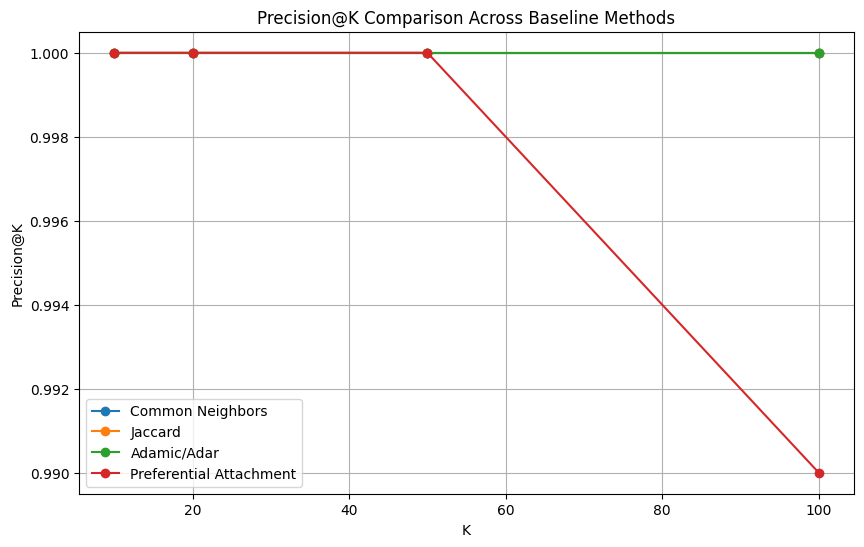

In [22]:
plt.figure(figsize=(10, 6))

for method in ranking_results["Method"].unique():
    subset = ranking_results[ranking_results["Method"] == method]
    plt.plot(subset["K"], subset["Precision@K"], marker="o", label=method)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Precision@K Comparison Across Baseline Methods")
plt.legend()
plt.grid(True)
plt.show()

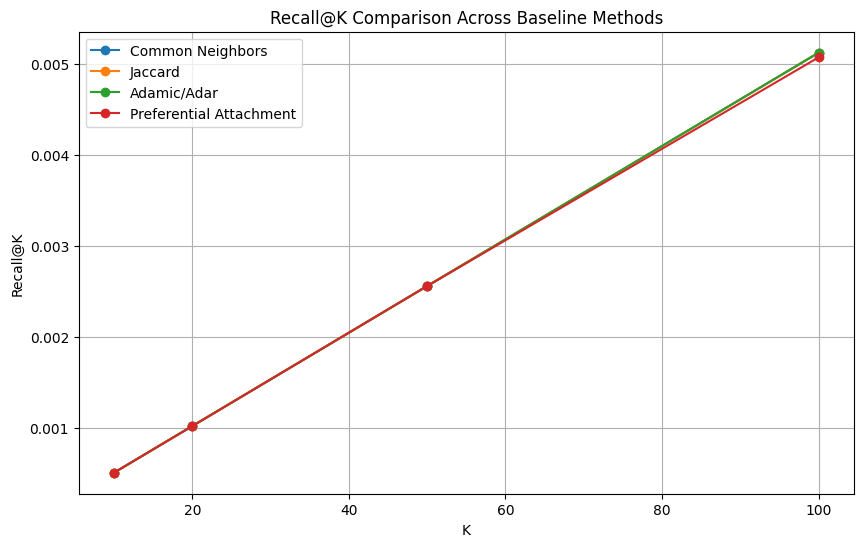

In [23]:
plt.figure(figsize=(10, 6))

for method in ranking_results["Method"].unique():
    subset = ranking_results[ranking_results["Method"] == method]
    plt.plot(subset["K"], subset["Recall@K"], marker="o", label=method)

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Recall@K Comparison Across Baseline Methods")
plt.legend()
plt.grid(True)
plt.show()

7.1 Harder Candidate Setting

In [24]:
def sample_hard_negative_edges(G, forbidden_edges, num_samples, seed=42):
    random.seed(seed)
    hard_negatives = set()

    nodes = list(G.nodes())

    while len(hard_negatives) < num_samples:
        u, v = random.sample(nodes, 2)
        edge = (min(u, v), max(u, v))

        if edge in forbidden_edges:
            continue
        if G.has_edge(u, v):
            continue
        if len(list(nx.common_neighbors(G, u, v))) == 0:
            continue

        hard_negatives.add(edge)

    return hard_negatives

In [25]:
hard_negative_edges = sample_hard_negative_edges(
    G_train,
    forbidden_edges=train_edges | predictable_future_edges,
    num_samples=len(predictable_future_edges),
    seed=42
)

hard_candidate_edges = list(predictable_future_edges) + list(hard_negative_edges)

hard_candidate_labels = {}
for edge in predictable_future_edges:
    hard_candidate_labels[edge] = 1
for edge in hard_negative_edges:
    hard_candidate_labels[edge] = 0

print(f"Number of hard negative edges: {len(hard_negative_edges)}")
print(f"Total number of hard candidate edges: {len(hard_candidate_edges)}")

Number of hard negative edges: 19512
Total number of hard candidate edges: 39024


In [26]:
def compute_baseline_scores_v2(G, candidate_edges, labels_dict):
    rows = []

    for u, v in candidate_edges:
        edge = (min(u, v), max(u, v))
        rows.append({
            "u": u,
            "v": v,
            "edge": edge,
            "label": labels_dict[edge],
            "common_neighbors": score_common_neighbors(G, u, v),
            "jaccard": score_jaccard(G, u, v),
            "adamic_adar": score_adamic_adar(G, u, v),
            "preferential_attachment": score_preferential_attachment(G, u, v)
        })

    return pd.DataFrame(rows)

In [27]:
hard_baseline_df = compute_baseline_scores_v2(G_train, hard_candidate_edges, hard_candidate_labels)

print("Hard setting baseline score table shape:", hard_baseline_df.shape)
hard_baseline_df.head()

Hard setting baseline score table shape: (39024, 8)


,u,v,edge,label,common_neighbors,jaccard,adamic_adar,preferential_attachment
0,64747,101052,"(64747, 101052)",1,9,0.236842,2.386878,420
1,28391,105798,"(28391, 105798)",1,1,0.076923,0.455120,13
2,492,10639,"(492, 10639)",1,10,0.068966,2.473142,5076
3,22105,74844,"(22105, 74844)",1,1,0.022222,0.233827,45
4,79187,101986,"(79187, 101986)",1,3,0.028302,0.806667,2760


In [28]:
hard_results_cn = evaluate_ranking(hard_baseline_df, "common_neighbors", k_values)
hard_results_jaccard = evaluate_ranking(hard_baseline_df, "jaccard", k_values)
hard_results_aa = evaluate_ranking(hard_baseline_df, "adamic_adar", k_values)
hard_results_pa = evaluate_ranking(hard_baseline_df, "preferential_attachment", k_values)

hard_ranking_results = pd.concat(
    [hard_results_cn, hard_results_jaccard, hard_results_aa, hard_results_pa],
    ignore_index=True
)

hard_ranking_results

,Method,K,Hits,Precision@K,Recall@K
0,common_neighbors,10,10,1.00,0.000513
1,common_neighbors,20,20,1.00,0.001025
2,common_neighbors,50,50,1.00,0.002563
3,common_neighbors,100,100,1.00,0.005125
4,jaccard,10,10,1.00,0.000513
5,jaccard,20,20,1.00,0.001025
6,jaccard,50,50,1.00,0.002563
7,jaccard,100,100,1.00,0.005125
8,adamic_adar,10,10,1.00,0.000513
9,adamic_adar,20,20,1.00,0.001025


In [29]:
hard_ranking_results["Method"] = hard_ranking_results["Method"].map(method_name_map)
hard_ranking_results

,Method,K,Hits,Precision@K,Recall@K
0,Common Neighbors,10,10,1.00,0.000513
1,Common Neighbors,20,20,1.00,0.001025
2,Common Neighbors,50,50,1.00,0.002563
3,Common Neighbors,100,100,1.00,0.005125
4,Jaccard,10,10,1.00,0.000513
5,Jaccard,20,20,1.00,0.001025
6,Jaccard,50,50,1.00,0.002563
7,Jaccard,100,100,1.00,0.005125
8,Adamic/Adar,10,10,1.00,0.000513
9,Adamic/Adar,20,20,1.00,0.001025


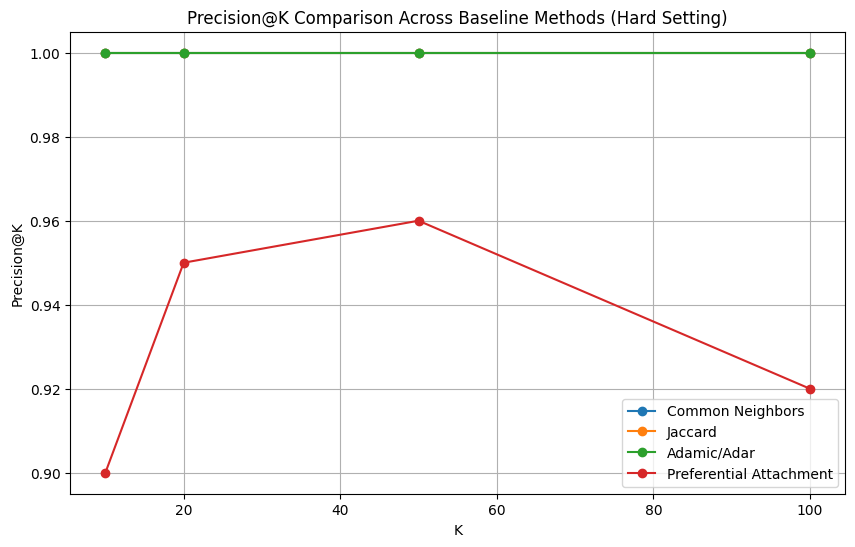

In [30]:
plt.figure(figsize=(10, 6))

for method in hard_ranking_results["Method"].unique():
    subset = hard_ranking_results[hard_ranking_results["Method"] == method]
    plt.plot(subset["K"], subset["Precision@K"], marker="o", label=method)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Precision@K Comparison Across Baseline Methods (Hard Setting)")
plt.legend()
plt.grid(True)
plt.show()

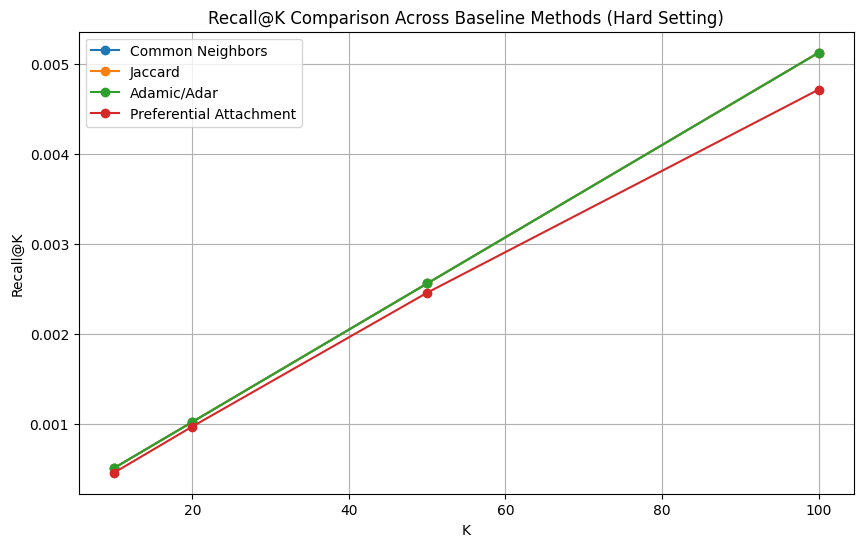

In [31]:
plt.figure(figsize=(10, 6))

for method in hard_ranking_results["Method"].unique():
    subset = hard_ranking_results[hard_ranking_results["Method"] == method]
    plt.plot(subset["K"], subset["Recall@K"], marker="o", label=method)

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Recall@K Comparison Across Baseline Methods (Hard Setting)")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
easy_results_labeled = ranking_results.copy()
easy_results_labeled["Setting"] = "Easy"

hard_results_labeled = hard_ranking_results.copy()
hard_results_labeled["Setting"] = "Hard"

combined_results = pd.concat([easy_results_labeled, hard_results_labeled], ignore_index=True)
combined_results

,Method,K,Hits,Precision@K,Recall@K,Setting
0,Common Neighbors,10,10,1.00,0.000513,Easy
1,Common Neighbors,20,20,1.00,0.001025,Easy
2,Common Neighbors,50,50,1.00,0.002563,Easy
3,Common Neighbors,100,100,1.00,0.005125,Easy
4,Jaccard,10,10,1.00,0.000513,Easy
5,Jaccard,20,20,1.00,0.001025,Easy
6,Jaccard,50,50,1.00,0.002563,Easy
7,Jaccard,100,100,1.00,0.005125,Easy
8,Adamic/Adar,10,10,1.00,0.000513,Easy
9,Adamic/Adar,20,20,1.00,0.001025,Easy


In [44]:
heldout_baseline_df = hard_baseline_df.loc[X_test.index].copy()
heldout_baseline_df.head()

,u,v,edge,label,common_neighbors,jaccard,adamic_adar,preferential_attachment
8812,38374,116780,"(38374, 116780)",1,6,0.076923,1.645072,1755
3670,48686,89915,"(48686, 89915)",1,12,0.107143,2.722054,3315
8309,79956,121118,"(79956, 121118)",1,34,0.276423,8.803468,5820
37155,43405,77480,"(43405, 77480)",0,2,0.009524,0.498449,6336
29456,122787,125915,"(122787, 125915)",0,2,0.013423,0.384832,4770


In [45]:
heldout_results_cn = evaluate_ranking(heldout_baseline_df, "common_neighbors", k_values)
heldout_results_jaccard = evaluate_ranking(heldout_baseline_df, "jaccard", k_values)
heldout_results_aa = evaluate_ranking(heldout_baseline_df, "adamic_adar", k_values)
heldout_results_pa = evaluate_ranking(heldout_baseline_df, "preferential_attachment", k_values)

heldout_baseline_results = pd.concat(
    [heldout_results_cn, heldout_results_jaccard, heldout_results_aa, heldout_results_pa],
    ignore_index=True
)

heldout_baseline_results["Method"] = heldout_baseline_results["Method"].map(method_name_map)
heldout_baseline_results

,Method,K,Hits,Precision@K,Recall@K
0,Common Neighbors,10,10,1.00,0.002563
1,Common Neighbors,20,20,1.00,0.005126
2,Common Neighbors,50,50,1.00,0.012814
3,Common Neighbors,100,100,1.00,0.025628
4,Jaccard,10,10,1.00,0.002563
5,Jaccard,20,19,0.95,0.004869
6,Jaccard,50,49,0.98,0.012558
7,Jaccard,100,99,0.99,0.025372
8,Adamic/Adar,10,10,1.00,0.002563
9,Adamic/Adar,20,20,1.00,0.005126


 8. Supervised Extension

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [34]:
feature_columns = [
    "common_neighbors",
    "jaccard",
    "adamic_adar",
    "preferential_attachment"
]

X = hard_baseline_df[feature_columns]
y = hard_baseline_df["label"]

print("Feature matrix shape:", X.shape)
print("Label distribution:")
print(y.value_counts())

Feature matrix shape: (39024, 4)
Label distribution:
label
1    19512
0    19512
Name: count, dtype: int64


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 31219
Test set size: 7805


In [36]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained.")

Logistic Regression model trained.


In [37]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      3903
           1       0.96      0.90      0.93      3902

    accuracy                           0.93      7805
   macro avg       0.93      0.93      0.93      7805
weighted avg       0.93      0.93      0.93      7805

ROC-AUC: 0.9731003093600016


In [38]:
supervised_results_df = X_test.copy()
supervised_results_df["label"] = y_test.values
supervised_results_df["predicted_probability"] = y_prob

supervised_results_df.head()

,common_neighbors,jaccard,adamic_adar,preferential_attachment,label,predicted_probability
8812,6,0.076923,1.645072,1755,1,0.951579
3670,12,0.107143,2.722054,3315,1,0.946701
8309,34,0.276423,8.803468,5820,1,1.000000
37155,2,0.009524,0.498449,6336,0,0.122440
29456,2,0.013423,0.384832,4770,0,0.045525


In [39]:
def evaluate_supervised_ranking(df, score_column, k_values):
    results = []

    ranked_df = df.sort_values(by=score_column, ascending=False).reset_index(drop=True)
    total_positive = df["label"].sum()

    for k in k_values:
        top_k = ranked_df.head(k)
        hits = top_k["label"].sum()
        precision_at_k = hits / k if k > 0 else 0
        recall_at_k = hits / total_positive if total_positive > 0 else 0

        results.append({
            "Method": "Logistic Regression",
            "K": k,
            "Hits": int(hits),
            "Precision@K": precision_at_k,
            "Recall@K": recall_at_k
        })

    return pd.DataFrame(results)

In [40]:
supervised_ranking_results = evaluate_supervised_ranking(
    supervised_results_df,
    score_column="predicted_probability",
    k_values=k_values
)

supervised_ranking_results

,Method,K,Hits,Precision@K,Recall@K
0,Logistic Regression,10,10,1.0,0.002563
1,Logistic Regression,20,20,1.0,0.005126
2,Logistic Regression,50,50,1.0,0.012814
3,Logistic Regression,100,100,1.0,0.025628


In [41]:
baseline_comparison_df = pd.concat(
    [hard_ranking_results, supervised_ranking_results],
    ignore_index=True
)

baseline_comparison_df

,Method,K,Hits,Precision@K,Recall@K
0,Common Neighbors,10,10,1.00,0.000513
1,Common Neighbors,20,20,1.00,0.001025
2,Common Neighbors,50,50,1.00,0.002563
3,Common Neighbors,100,100,1.00,0.005125
4,Jaccard,10,10,1.00,0.000513
5,Jaccard,20,20,1.00,0.001025
6,Jaccard,50,50,1.00,0.002563
7,Jaccard,100,100,1.00,0.005125
8,Adamic/Adar,10,10,1.00,0.000513
9,Adamic/Adar,20,20,1.00,0.001025


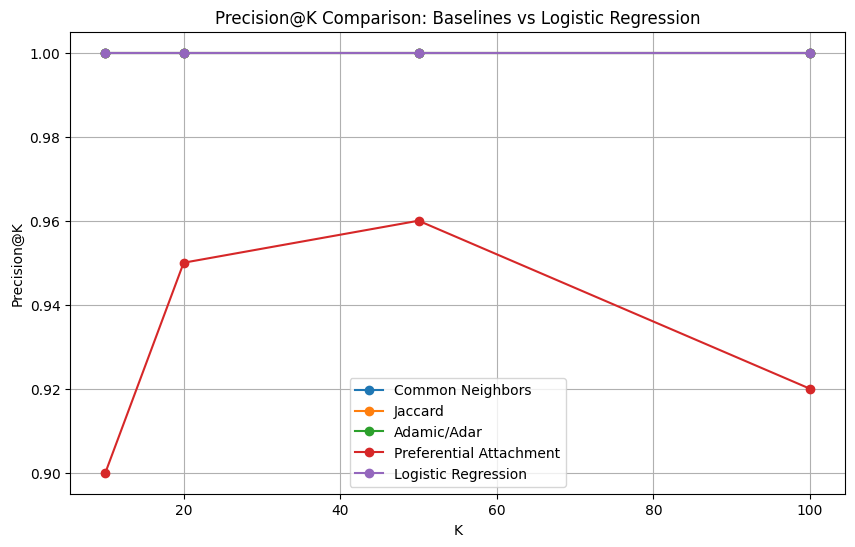

In [42]:
plt.figure(figsize=(10, 6))

for method in baseline_comparison_df["Method"].unique():
    subset = baseline_comparison_df[baseline_comparison_df["Method"] == method]
    plt.plot(subset["K"], subset["Precision@K"], marker="o", label=method)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Precision@K Comparison: Baselines vs Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

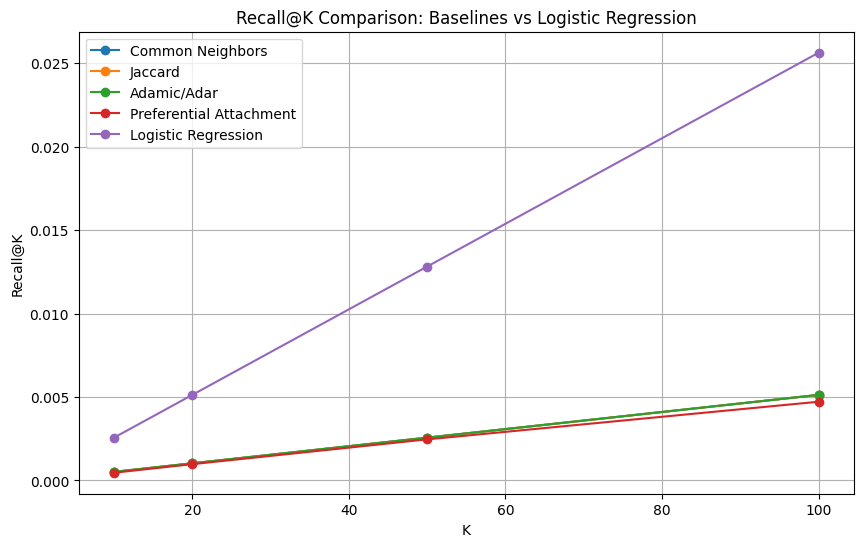

In [43]:
plt.figure(figsize=(10, 6))

for method in baseline_comparison_df["Method"].unique():
    subset = baseline_comparison_df[baseline_comparison_df["Method"] == method]
    plt.plot(subset["K"], subset["Recall@K"], marker="o", label=method)

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Recall@K Comparison: Baselines vs Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

9. Result Comparison and Discussion

In [46]:
fair_comparison_df = pd.concat(
    [heldout_baseline_results, supervised_ranking_results],
    ignore_index=True
)

fair_comparison_df

,Method,K,Hits,Precision@K,Recall@K
0,Common Neighbors,10,10,1.00,0.002563
1,Common Neighbors,20,20,1.00,0.005126
2,Common Neighbors,50,50,1.00,0.012814
3,Common Neighbors,100,100,1.00,0.025628
4,Jaccard,10,10,1.00,0.002563
5,Jaccard,20,19,0.95,0.004869
6,Jaccard,50,49,0.98,0.012558
7,Jaccard,100,99,0.99,0.025372
8,Adamic/Adar,10,10,1.00,0.002563
9,Adamic/Adar,20,20,1.00,0.005126


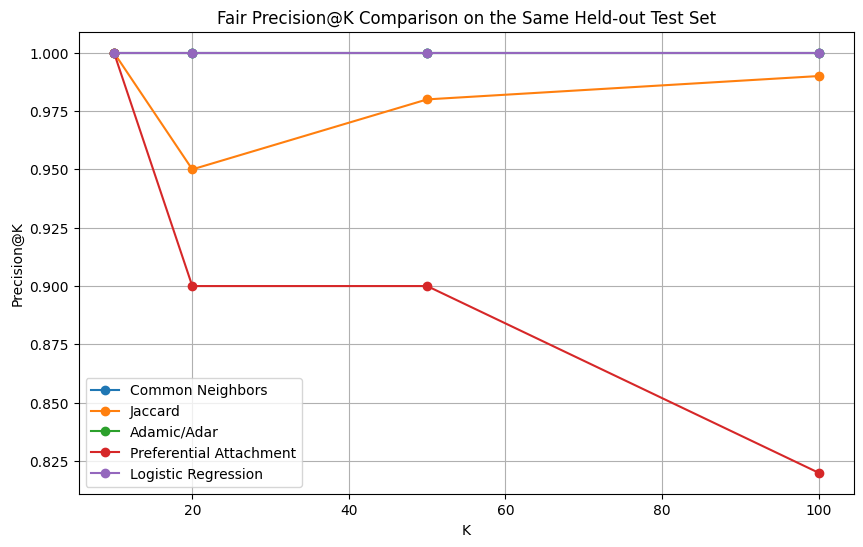

In [47]:
plt.figure(figsize=(10, 6))

for method in fair_comparison_df["Method"].unique():
    subset = fair_comparison_df[fair_comparison_df["Method"] == method]
    plt.plot(subset["K"], subset["Precision@K"], marker="o", label=method)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Fair Precision@K Comparison on the Same Held-out Test Set")
plt.legend()
plt.grid(True)
plt.show()

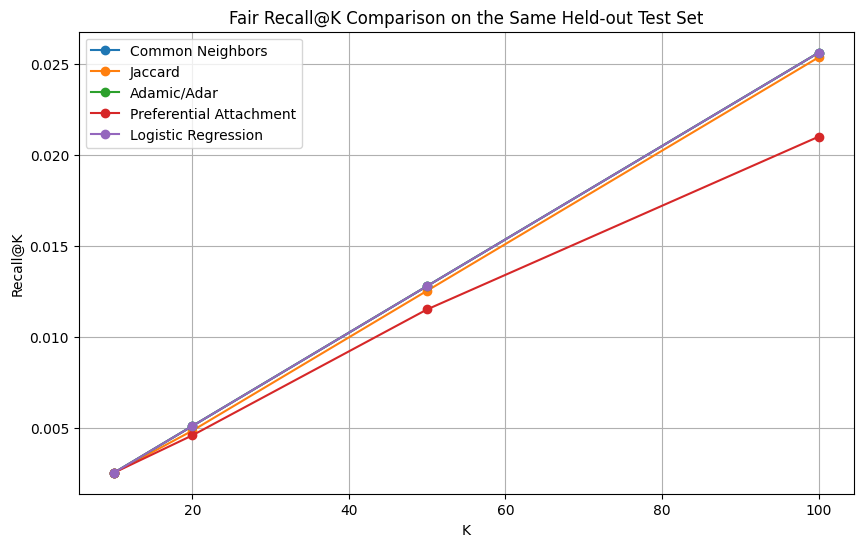

In [48]:
plt.figure(figsize=(10, 6))

for method in fair_comparison_df["Method"].unique():
    subset = fair_comparison_df[fair_comparison_df["Method"] == method]
    plt.plot(subset["K"], subset["Recall@K"], marker="o", label=method)

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Fair Recall@K Comparison on the Same Held-out Test Set")
plt.legend()
plt.grid(True)
plt.show()